In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import featuregraph as fg
from featuregraph import get_block_coordinates, get_output_cells, get_valid_transformations, get_candidate_transformations, get_instruction_layout, plot_arc_agi

In [9]:
train_input_1 = np.array([
    [1, 2, 3],
    [4, 5, 6],
])

train_output_1 = np.array([
    [1, 2, 3, 3, 2, 1, 4, 5, 6],
    [4, 5, 6, 6, 5, 4, 1, 2, 3],
    [4, 5, 6, 1, 2, 3, 3, 2, 1],
    [1, 2, 3, 4, 5, 6, 6, 5, 4],
])

train_input_2 = np.array([
    [7, 2],
    [4, 9],
    [1, 6],
])

train_output_2 = np.array([
    [7, 2, 2, 7, 1, 6],
    [4, 9, 9, 4, 4, 9],
    [1, 6, 6, 1, 7, 2],
    [1, 6, 7, 2, 2, 7],
    [4, 9, 4, 9, 9, 4],
    [7, 2, 1, 6, 6, 1],
])

training_pairs = [
    {
        "input": train_input_1,
        "output": train_output_1,
    },
    {
        "input": train_input_2,
        "output": train_output_2,
    },
]

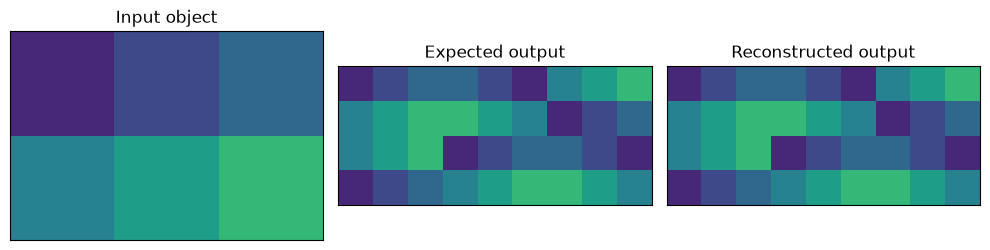

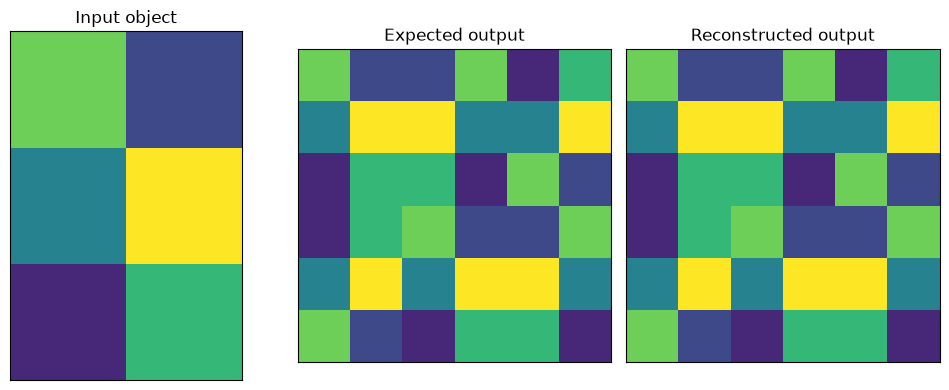

In [10]:
for t in training_pairs:
    input = t['input']
    output = t['output']

    input_flip_horizontal = np.fliplr(input)
    input_flip_vertical = np.flipud(input)
    input_rotate_90 = np.rot90(input, k=1) 
    input_rotate_180 = np.rot90(input, k=2) 
    input_rotate_270 = np.rot90(input, k=3)

    all_candidate_transformations = [
        input,
        input_flip_horizontal,
        input_flip_vertical,
        input_rotate_90,
        input_rotate_180,
        input_rotate_270
    ]

    input_height, input_width = input.shape
    output_height, output_width = output.shape

    number_of_block_rows = output_height // input_height
    number_of_block_columns = output_width // input_width

    block_coordinates = get_block_coordinates(input.shape, output.shape)
    valid_transformations = get_valid_transformations(all_candidate_transformations, input.shape)
    candidate_transformations = np.array([get_candidate_transformations(v, block_coordinates) for v in valid_transformations]).T

    instruction_layout = get_instruction_layout(input_height, input_width, output, number_of_block_rows, number_of_block_columns, candidate_transformations)

    cell_indices = np.arange(candidate_transformations.shape[0])
    cell_instructions = instruction_layout[block_coordinates[:,0], block_coordinates[:,1]]
    manual_output = candidate_transformations[cell_indices, cell_instructions].reshape(output.shape)

    plot_arc_agi(input, output, manual_output)